# Tutorial 2: Neural Data Formats and Processors

In Tutorial 1, our data was already in its simplest form: a matrix of
independent samples, shape `(n_samples, n_channels)`, ready to be passed
directly to `nmi.run()`. No windowing, no alignment, no format conversion.

Real neural recordings never look like that. You might have:
- A continuous LFP trace recorded at 1000 Hz for 10 minutes
- A list of spike timestamps, one array per neuron
- A sequence of discrete behavioral state labels (resting, running, grooming)
- A pre-binned spike count matrix where rows are time bins and columns are neurons

In all of these cases, the raw data cannot be fed directly to a neural network.
It must first be **processed**: sliced into windows, encoded into a fixed-size
tensor, and aligned across modalities. This tutorial shows exactly how that
processing works — and builds the intuition for the 3D tensor
`(n_samples, n_channels, window_size)` that every model in the library consumes.

We use `nmi.data.handler.create_dataset` directly here so we can inspect the
intermediate tensor at each step. In practice, you never need to call this
yourself — `nmi.run()` calls it for you when you specify `processor_type_x`
and `processor_type_y`. Think of this tutorial as opening the hood.

## 1. The Core Idea: Non-Overlapping Windows and Dynamic Jittering

Before looking at specific data formats, it is worth understanding the
windowing strategy the library uses — because it is different from the
naive sliding-window approach.

**The naive approach** takes a sliding window (e.g., 100 ms), shifts by
1 ms, takes another window, and so on. For 10 minutes of 1000 Hz data
this produces ~600,000 overlapping 100-sample windows. Storing all of
them as a 3D array simultaneously will exhaust GPU memory for any
realistic recording.

**NeuralMI's approach** uses two ideas:

1. **Non-overlapping blocks.** The recording is chopped into strictly
   non-overlapping windows at processing time. 10 minutes at 1000 Hz
   with a 100 ms window gives exactly 6,000 non-overlapping samples —
   a tiny fraction of the naive approach's memory cost.

2. **Dynamic jittering.** To prevent the network from memorising arbitrary
   block boundaries, the trainer randomly shifts the starting point of all
   blocks at the beginning of every training epoch. Over many epochs the
   network effectively sees every possible alignment of the data, learning
   shift-invariant features without ever materialising the full sliding-window
   array. This happens entirely inside the trainer and requires no action from
   the user.

The rest of this tutorial shows how each raw data format maps onto this scheme.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")

## 2. Continuous Data (LFP, EEG, Calcium Imaging, Kinematics)

Continuous recordings are the most common neural data format. Whether you
are recording local field potentials, EEG, calcium fluorescence, or
joint kinematics, the format is the same: a matrix of shape
`(n_timepoints, n_channels)` — **timepoints first, channels second**.

This is the convention the library's continuous processor expects.
Note that it matches the standard NumPy/pandas convention where rows are
observations (timepoints) and columns are features (channels).

We generate a simple synthetic signal: a sine wave with 4 channels,
sampled at 1000 timepoints.

In [2]:
# Four slightly phase-shifted sine waves, one per channel.
# Shape: (n_timepoints, n_channels) = (1000, 4) — timepoints first.
n_timepoints = 1000
n_channels = 4
raw_continuous = np.column_stack([
    np.sin(np.linspace(i, 20 * np.pi + i, n_timepoints)) for i in range(n_channels)
])
print(f"raw_continuous.shape: {raw_continuous.shape}")
# Expected: (1000, 4) — (n_timepoints, n_channels)

raw_continuous.shape: (1000, 4)


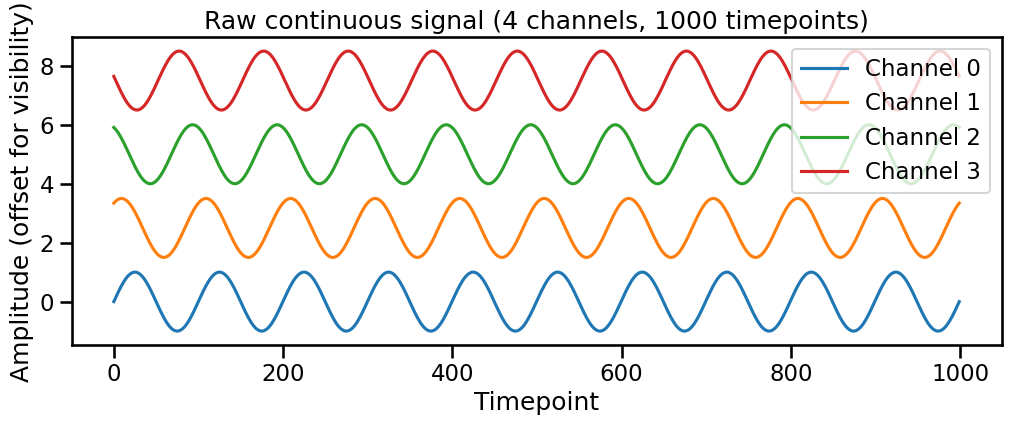

In [3]:
# Visualise all 4 channels as a time series, offset vertically for visibility.
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(n_channels):
    ax.plot(raw_continuous[:, i] + i * 2.5, label=f"Channel {i}")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Amplitude (offset for visibility)")
ax.set_title(f"Raw continuous signal ({n_channels} channels, {n_timepoints} timepoints)")
ax.legend(loc="upper right")
plt.show()

In [4]:
# Process the continuous signal into non-overlapping windows.
# window_size=100 timepoints → 1000 / 100 = 10 non-overlapping windows.
# nmi.run() applies this automatically via processing=Processing(x='continuous').
window_size = 100

dataset = nmi.data.handler.create_dataset(
    x_data=raw_continuous,
    processor_type_x='continuous',
    processor_params_x={'window_size': window_size}
)

processed = dataset.x_data.cpu().numpy()
print(f"Raw shape:       {raw_continuous.shape}  (n_timepoints, n_channels)")
print(f"Processed shape: {processed.shape}  (n_windows, n_channels, window_size)")
print(f"\nExpected: {n_timepoints} timepoints / {window_size} per window = {n_timepoints // window_size} windows")

2026-03-06 10:17:13 - neural_mi - INFO - Window coverage: 10/10 windows have sufficient data
2026-03-06 10:17:13 - neural_mi - INFO - Created 10 aligned windows


Raw shape:       (1000, 4)  (n_timepoints, n_channels)
Processed shape: (10, 4, 101)  (n_windows, n_channels, window_size)

Expected: 1000 timepoints / 100 per window = 10 windows


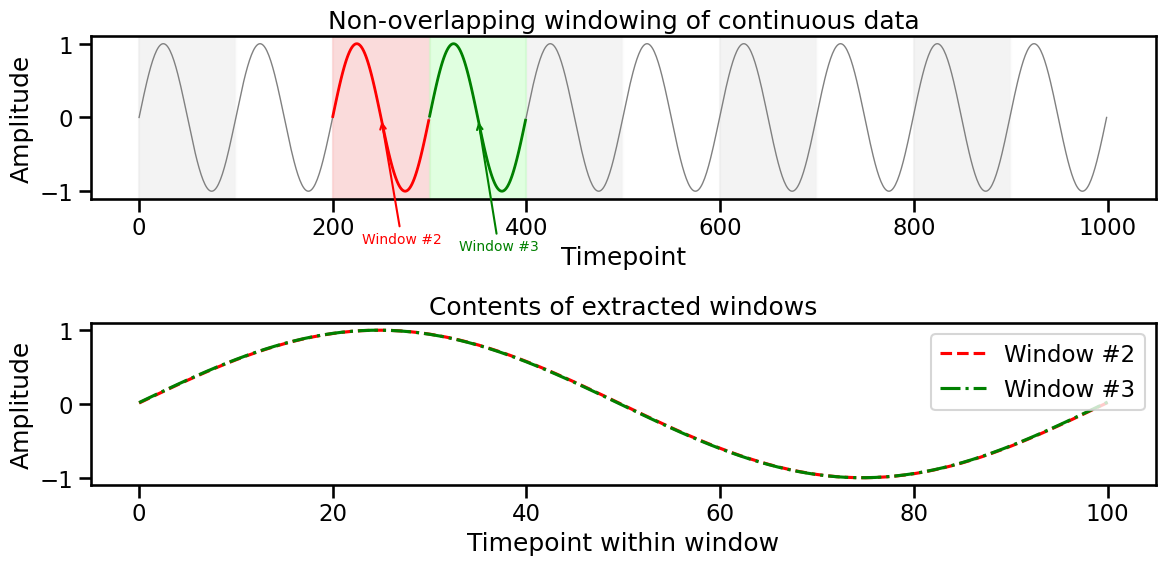

In [7]:
# Visualise the windowing: show the raw channel-0 signal with window boundaries
# and highlight two consecutive extracted windows.
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 6))

# --- Top: raw signal with shaded windows ---
raw_ch0 = raw_continuous[:, 0]
ax_top.plot(raw_ch0, color='grey', linewidth=1)

# Alternating grey/white shading for context
for w in range(10):
    color = '#e8e8e8' if w % 2 == 0 else 'white'
    ax_top.axvspan(w * window_size, (w + 1) * window_size, color=color, alpha=0.5)

# Highlight window #2 in red, window #3 in green
ax_top.axvspan(2 * window_size, 3 * window_size, color='#ffcccc', alpha=0.6)
ax_top.axvspan(3 * window_size, 4 * window_size, color='#ccffcc', alpha=0.6)
# Overlay raw signal in the highlighted regions
t_w2 = np.arange(2 * window_size, 3 * window_size)
t_w3 = np.arange(3 * window_size, 4 * window_size)
ax_top.plot(t_w2, raw_ch0[t_w2], color='red', linewidth=2)
ax_top.plot(t_w3, raw_ch0[t_w3], color='green', linewidth=2)
ax_top.annotate("Window #2", xy=(2.5 * window_size, raw_ch0[int(2.5 * window_size)]),
                xytext=(230, -1.7), fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))
ax_top.annotate("Window #3", xy=(3.5 * window_size, raw_ch0[int(3.5 * window_size)]),
                xytext=(330, -1.8), fontsize=10, color='green',
                arrowprops=dict(arrowstyle='->', color='green'))
ax_top.set_title("Non-overlapping windowing of continuous data")
ax_top.set_xlabel("Timepoint")
ax_top.set_ylabel("Amplitude")

# --- Bottom: contents of extracted windows ---
ax_bot.plot(processed[2, 0, :], color='red', ls='--', label="Window #2")
ax_bot.plot(processed[3, 0, :], color='green', ls='-.', label="Window #3")
ax_bot.set_xlabel("Timepoint within window")
ax_bot.set_ylabel("Amplitude")
ax_bot.set_title("Contents of extracted windows")
ax_bot.legend()

plt.tight_layout()
plt.show()

The processed tensor is `(n_windows, n_channels, window_size)` — this is the
**internal 3D format** used throughout the library. When you call `nmi.run()`
with `processor_type_x='continuous'`, this transformation happens automatically
before any model sees the data.

## 3. Spike Train Data (Raw Spike Times)

Spike data is fundamentally different from continuous recordings.
Rather than a regular matrix of values, it is an **irregular list of events**:
a list of arrays, one per neuron, where each array contains the times at which
that neuron fired. Neurons fire at different rates and at different moments,
so the arrays have different lengths.

NeuralMI represents raw spike data as `List[np.ndarray]` — one 1D array of
spike timestamps per neuron. The processor must convert this irregular format
into the regular 3D tensor the network expects.

Two things happen during spike processing:

1. **Relative times.** Spike times are converted from absolute timestamps
   (e.g., 1.84 s into the recording) to times relative to the start of their
   window (e.g., 0.34 s into window #3). This makes the network shift-invariant:
   it learns features of the spike pattern, not the absolute time.

2. **Padding.** Each window can contain a different number of spikes.
   To create a regular tensor, windows are padded with a sentinel value
   (`-1.0` by default) up to a fixed maximum length. The sentinel is negative
   so it is unambiguous: relative spike times within a window are always ≥ 0.

Let's generate some spike data and watch this transformation happen.

In [8]:
spike_data, _ = nmi.generators.generate_correlated_spike_trains(
    n_neurons=5,
    duration=2.0,
    firing_rate=15.0
)

print(f"Number of neurons: {len(spike_data)}")
for i, neuron_spikes in enumerate(spike_data):
    print(f"  Neuron {i}: {len(neuron_spikes)} spikes, "
          f"first 3 times = {np.round(neuron_spikes[:3], 3)}")

Number of neurons: 5
  Neuron 0: 33 spikes, first 3 times = [0.069 0.077 0.156]
  Neuron 1: 39 spikes, first 3 times = [0.093 0.117 0.119]
  Neuron 2: 29 spikes, first 3 times = [0.052 0.11  0.165]
  Neuron 3: 40 spikes, first 3 times = [0.022 0.083 0.091]
  Neuron 4: 23 spikes, first 3 times = [0.015 0.066 0.091]


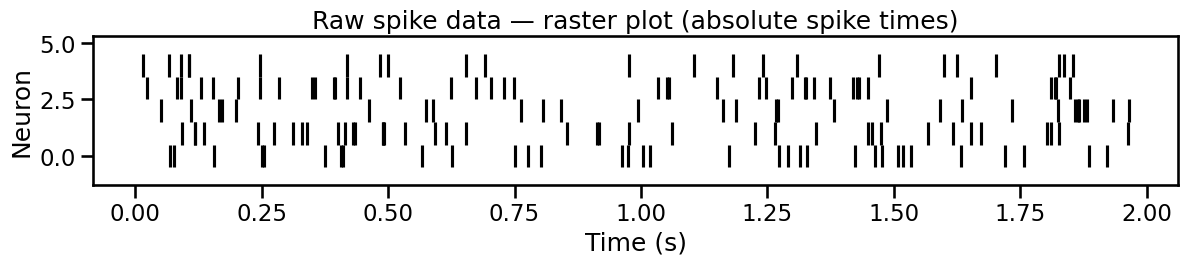

In [9]:
# Raster plot: each row is a neuron, each tick is a spike.
fig, ax = plt.subplots(figsize=(12, 3))
ax.eventplot(spike_data, color='black')
ax.set_title("Raw spike data — raster plot (absolute spike times)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Neuron")
plt.tight_layout()
plt.show()

In [10]:
# Process spike times into non-overlapping windows.
# window_size_s=0.5 → 2.0 s / 0.5 s per window = 4 non-overlapping windows.
# nmi.run() applies this automatically via processing=Processing(x='spike').
window_size_s = 0.5

dataset_spike = nmi.data.handler.create_dataset(
    x_data=spike_data,
    processor_type_x='spike',
    processor_params_x={'window_size': window_size_s}
)

processed_spikes = dataset_spike.x_data.cpu().numpy()
print(f"Processed spike tensor shape: {processed_spikes.shape}")
print("  -> (n_windows, n_neurons, max_spikes_per_window)")
print(f"\nExpected: 2.0 s / {window_size_s} s per window = "
      f"{int(2.0 / window_size_s)} non-overlapping windows")

2026-03-06 10:18:19 - neural_mi - INFO - Window coverage: 4/4 windows have sufficient data
2026-03-06 10:18:19 - neural_mi - INFO - Created 4 aligned windows


Processed spike tensor shape: (4, 5, 18)
  -> (n_windows, n_neurons, max_spikes_per_window)

Expected: 2.0 s / 0.5 s per window = 4 non-overlapping windows


In [11]:
# Inspect window #1 (0.5 s to 1.0 s): spike times are now relative to window start.
# Padding value is -1.0 (unambiguously not a spike, since offsets are always ≥ 0).
sample_window = 1
print(f"\n--- Window #{sample_window} ({sample_window * window_size_s:.1f}s "
      f"to {(sample_window+1) * window_size_s:.1f}s) ---")
print("Spike times are now RELATIVE to window start. -1.0 = padding (no spike).\n")
for i in range(len(spike_data)):
    content = processed_spikes[sample_window, i, :]
    print(f"  Neuron {i}: {np.round(content, 3)}")


--- Window #1 (0.5s to 1.0s) ---
Spike times are now RELATIVE to window start. -1.0 = padding (no spike).

  Neuron 0: [ 0.053  0.112  0.236  0.262  0.287  0.448  0.46   0.489 -1.    -1.
 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
  Neuron 1: [ 0.019  0.078  0.1    0.139  0.339  0.399  0.403  0.461 -1.    -1.
 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
  Neuron 2: [ 0.06   0.073  0.249  0.293  0.327  0.48  -1.    -1.    -1.    -1.
 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
  Neuron 3: [ 0.009  0.11   0.159  0.19   0.215  0.233 -1.    -1.    -1.    -1.
 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]
  Neuron 4: [ 0.139  0.176  0.462 -1.    -1.    -1.    -1.    -1.    -1.    -1.
 -1.    -1.    -1.    -1.    -1.    -1.    -1.    -1.   ]


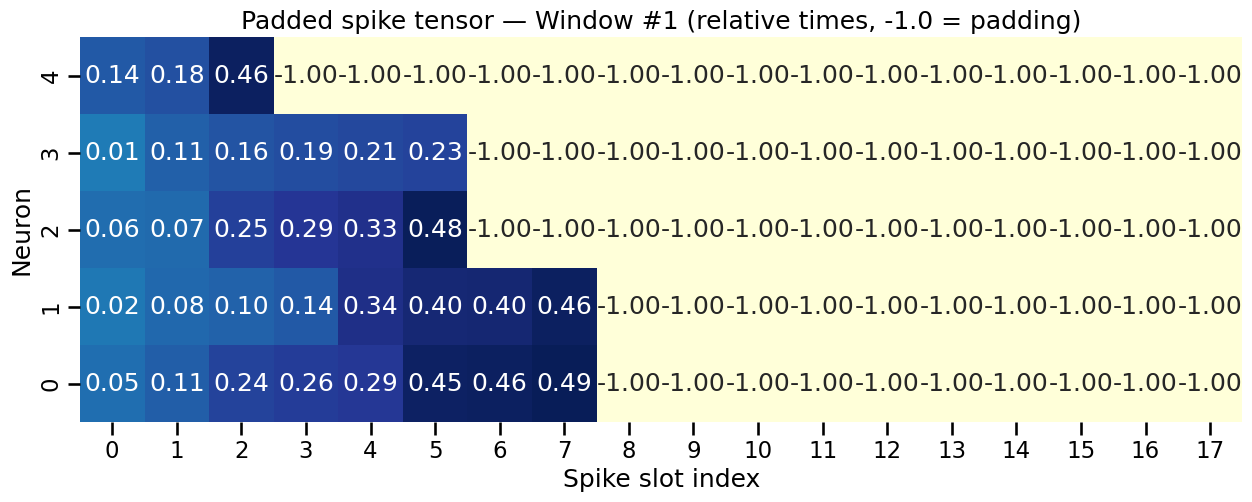

In [12]:
# Heatmap of the padded spike tensor for window #1.
# Rows = neurons, columns = spike slots. Values are relative spike times or -1.0 (padding).
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(processed_spikes[sample_window], annot=True, fmt=".2f",
            cmap='YlGnBu', cbar=False, ax=ax)
ax.invert_yaxis()
ax.set_title(f"Padded spike tensor — Window #{sample_window} (relative times, -1.0 = padding)")
ax.set_xlabel("Spike slot index")
ax.set_ylabel("Neuron")
plt.show()

## 4. Binned Spike Data (Spike Counts in a Matrix)

In many workflows — including several public datasets — spike data is not
provided as raw timestamps. Instead it arrives pre-binned: a matrix of shape
`(n_timepoints, n_neurons)` where each entry is the spike count (often 0 or 1)
in a short time bin. The hippocampal and Allen Brain datasets we use in
Tutorial 7 are in exactly this format.

**Which processor should you use for this format?**
The spike processor expects raw timestamps. The pre-processed path (`None`)
expects independent samples with no further windowing needed. Neither fits.

The correct choice is `processor_type='continuous'`. The continuous processor
does not care whether the values in your matrix are voltages, firing rates, or
binary spike counts — it only sees a `(n_timepoints, n_channels)` matrix and
applies windowing. The biological meaning of the values is irrelevant to the
processor.

To demonstrate this concretely, we take the spike times we just generated and
**bin them** into a count matrix using numpy, then treat the resulting matrix
as continuous input.

In [ ]:
# The library has an internal BinnedSpikeDataset class (triggered by passing
# 'bin_size' in processor_params_x with processor_type='spike')
# handles binning per-window inside the pipeline, but does not produce a standalone
# matrix. We bin manually here using numpy.

bin_size = 0.01  # 10 ms bins
duration = 2.0   # recording duration of spike_data
bins = np.arange(0, duration + bin_size, bin_size)
n_bins = len(bins) - 1
n_neurons = len(spike_data)

# Build (n_timepoints_binned, n_neurons) matrix — timepoints first,
# the correct convention for the continuous processor.
binned_spikes = np.zeros((n_bins, n_neurons))
for i, neuron_spikes in enumerate(spike_data):
    counts, _ = np.histogram(neuron_spikes, bins=bins)
    binned_spikes[:, i] = counts

print(f"Binned spike matrix shape: {binned_spikes.shape}")
print(f"  -> (n_timepoints, n_neurons) — same convention as raw continuous data")
print(f"Value range: min={binned_spikes.min():.0f}, max={binned_spikes.max():.0f}")
print(f"Fraction of non-zero bins: {(binned_spikes > 0).mean():.3f}")

Binned spike matrix shape: (200, 5)
  -> (n_timepoints, n_neurons) — same convention as raw continuous data
Value range: min=0, max=2
Fraction of non-zero bins: 0.152


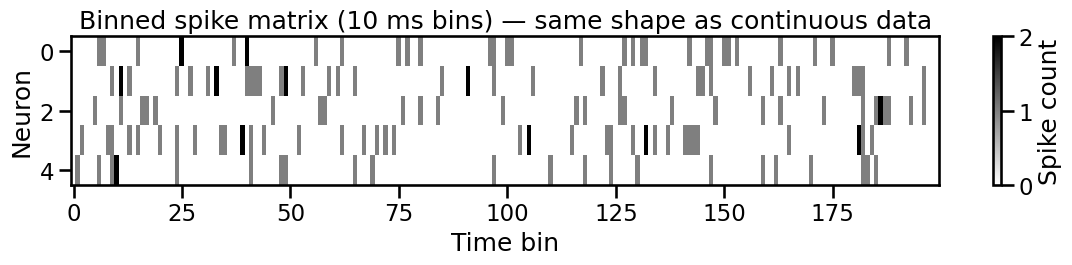

In [14]:
# Visualise the binned spike matrix as an image.
# The transposed view (neurons × timebins) gives the familiar raster-like layout.
fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(binned_spikes.T, aspect='auto', cmap='binary',
               interpolation='nearest')
fig.colorbar(im, ax=ax, label="Spike count")
ax.set_xlabel("Time bin")
ax.set_ylabel("Neuron")
ax.set_title("Binned spike matrix (10 ms bins) — same shape as continuous data")
plt.tight_layout()
plt.show()

In [15]:
# Now process the binned spike matrix as a continuous signal.
# window_size_bins=50 bins × 10 ms = 500 ms windows.
# nmi.run() applies this automatically via processing=Processing(x='continuous').
window_size_bins = 50  # 50 bins × 10 ms = 500 ms windows

dataset_binned = nmi.data.handler.create_dataset(
    x_data=binned_spikes,
    processor_type_x='continuous',
    processor_params_x={'window_size': window_size_bins}
)

processed_binned = dataset_binned.x_data.cpu().numpy()
print(f"Binned spikes processed shape: {processed_binned.shape}")
print("  -> (n_windows, n_neurons, window_size_bins)")

2026-03-06 10:19:43 - neural_mi - INFO - Window coverage: 4/4 windows have sufficient data
2026-03-06 10:19:43 - neural_mi - INFO - Created 4 aligned windows


Binned spikes processed shape: (4, 5, 51)
  -> (n_windows, n_neurons, window_size_bins)


The output shape is identical to what the continuous processor produces for
LFP data. From the network's perspective there is no difference: both are
`(n_samples, n_channels, window_size)` tensors. **The rule:** if your spike data
arrives as timestamps, use `processor_type='spike'`. If it arrives as a count
matrix (already binned), use `processor_type='continuous'`.

## 5. Categorical Data (Behavioral States, Stimulus Labels)

Categorical data represents discrete states at each timepoint — for example,
a behavioral label (0 = resting, 1 = running, 2 = grooming) or a stimulus
identity (one of N visual categories). The format is `(n_timepoints, n_channels)`
of integers, the same timepoints-first convention as continuous data.

The categorical processor encodes each window as the **majority-vote** category:
the most common label within the window is represented as a one-hot vector
of length `n_categories`. Each window becomes a `(n_channels, n_categories)`
tensor. This encoding lets the network treat categorical sequences as fixed-size
vectors without imposing any ordinal relationship between categories.

Raw categorical shape: (100, 1)  (n_timepoints, n_channels)
Unique labels: [0 1 2]


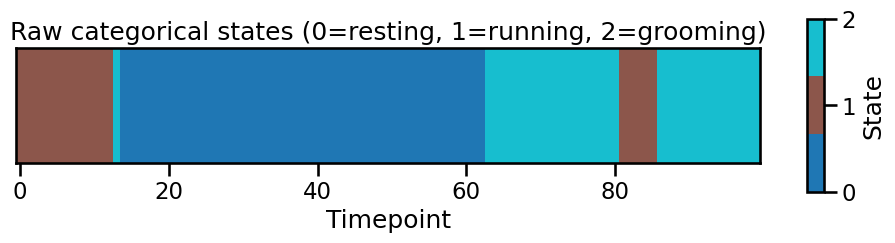

In [16]:
# generate_correlated_categorical_series returns shape (n_samples, n_channels)
# = (n_timepoints, n_channels) — timepoints first, ready for the processor.
raw_cat, _ = nmi.generators.generate_correlated_categorical_series(
    n_samples=100,
    n_channels=1,
    n_categories=3,
    use_torch=False
)
print(f"Raw categorical shape: {raw_cat.shape}  (n_timepoints, n_channels)")
print(f"Unique labels: {np.unique(raw_cat)}")

# Visualise as a 1D image. Transpose to (1, 100) for a wide horizontal layout.
# Make colorbar discrete with 3 distinct colors for the 3 categories.
fig, ax = plt.subplots(figsize=(12, 1.5))
# specify a color map with exactly 3 distinct colors for the 3 categories
cmap = plt.get_cmap('tab10', 3)  # 3 distinct colors for 3 categories
im = ax.imshow(raw_cat.T, aspect='auto', cmap=cmap, interpolation='nearest')
ax.set_title("Raw categorical states (0=resting, 1=running, 2=grooming)")
ax.set_xlabel("Timepoint")
ax.set_yticks([])
fig.colorbar(im, ax=ax, ticks=[0, 1, 2], label="State", shrink=1.5, aspect=10)
plt.show()

In [17]:
# Process categorical data: 5-timepoint windows → majority-vote one-hot encoding.
# nmi.run() applies this automatically via processing=Processing(x='categorical').
window_size_cat = 5  # 5 timepoints per window → 100 / 5 = 20 windows

dataset_cat = nmi.data.handler.create_dataset(
    x_data=raw_cat,
    processor_type_x='categorical',
    processor_params_x={'window_size': window_size_cat}
)

processed_cat = dataset_cat.x_data.cpu().numpy()
# Majority-vote encoding: each window → one-hot of the dominant category.
# Shape: (n_windows, n_channels, n_categories)
print(f"Raw states in window #0:      {raw_cat[:window_size_cat, 0]}")
print(f"Majority-vote one-hot (w=0):  {processed_cat[0, 0, :]}")
print(f"\nProcessed shape: {processed_cat.shape}")
print("  -> (n_windows, n_channels, n_categories) — majority-vote encoding")

2026-03-06 10:19:58 - neural_mi - INFO - Window coverage: 20/20 windows have sufficient data
2026-03-06 10:19:58 - neural_mi - INFO - Created 20 aligned windows


Raw states in window #0:      [1 1 1 1 1]
Majority-vote one-hot (w=0):  [0. 1. 0.]

Processed shape: (20, 1, 3)
  -> (n_windows, n_channels, n_categories) — majority-vote encoding


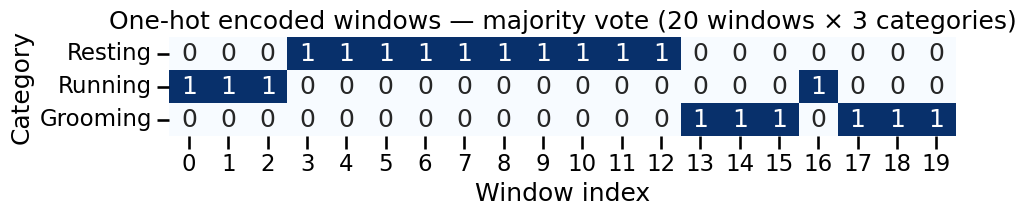

In [18]:
# Visualise majority-vote encoding across all 20 windows.
# Rows = categories, columns = windows. Each column has exactly one 1.0 entry.
fig, ax = plt.subplots(figsize=(10, 2.5))
# processed_cat[:, 0, :] shape: (n_windows=20, n_categories=3) → transpose for heatmap
sns.heatmap(processed_cat[:, 0, :].T, annot=True, fmt=".0f",
            cmap='Blues', cbar=False, ax=ax,
            yticklabels=['Resting', 'Running', 'Grooming'])
ax.set_xlabel("Window index")
ax.set_ylabel("Category")
ax.set_title("One-hot encoded windows — majority vote (20 windows × 3 categories)")
plt.tight_layout()
plt.show()

## 6. Aligning Multiple Data Streams

What if you want to relate LFP data (continuous) to spike trains, or
kinematics (continuous) to behavioral labels (categorical)? The two streams
may span different durations or have different sampling rates.

`create_dataset` handles this automatically. It processes each stream
independently with its own processor, computes how many non-overlapping windows
fit in each stream, and **truncates both to the smaller count**.
The result is always a pair of tensors with the same number of samples — ready
for MI estimation.

Below, we align a 10-second continuous signal with a spike recording that covers
only 8 seconds. We expect 10 windows from the continuous signal and 8 from the
spikes; the library should return 8 aligned windows from both.

In [19]:
# 10 seconds of continuous data at 100 Hz = 1000 timepoints, 2 channels.
# Shape: (n_timepoints, n_channels) — timepoints first.
x_cont = np.random.randn(1000, 2)
x_time = np.linspace(0, 10.0, 1000)  # needed to set the real-world time domain

# Spike recording spanning only 8 seconds.
y_spikes, _ = nmi.generators.generate_correlated_spike_trains(
    n_neurons=5, duration=8.0, firing_rate=10.0
)

# nmi.run() calls this automatically — shown here to make the alignment visible.
dataset_aligned = nmi.data.handler.create_dataset(
    x_data=x_cont,
    x_time=x_time,
    y_data=y_spikes,
    processor_type_x='continuous',
    processor_type_y='spike',
    processor_params_x={'window_size': 1.0},  # 1-second windows
    processor_params_y={'window_size': 1.0}
)

print("--- Alignment result ---")
print(f"Continuous spans 10 s  →  10 windows expected")
print(f"Spikes span 8 s        →   8 windows expected")
print(f"X (continuous) shape:  {dataset_aligned.x_data.shape}")
print(f"Y (spike) shape:       {dataset_aligned.y_data.shape}")
print(f"\nBoth truncated to 8 windows — ready for joint MI estimation.")

2026-03-06 10:20:08 - neural_mi - INFO - Window coverage: 8/8 windows have sufficient data
2026-03-06 10:20:08 - neural_mi - INFO - Created 8 aligned windows


--- Alignment result ---
Continuous spans 10 s  →  10 windows expected
Spikes span 8 s        →   8 windows expected
X (continuous) shape:  torch.Size([8, 2, 101])
Y (spike) shape:       torch.Size([8, 5, 19])

Both truncated to 8 windows — ready for joint MI estimation.


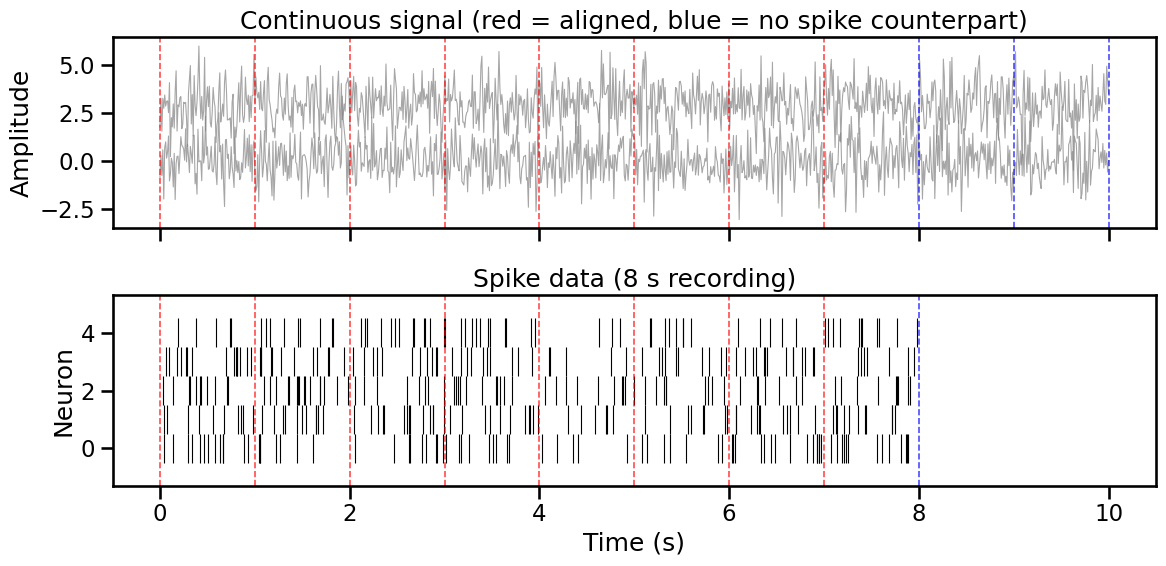

In [20]:
# Visualise the alignment: where does the shorter (spike) stream run out?
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- Top: continuous signal ---
for ch in range(2):
    ax_top.plot(x_time, x_cont[:, ch] + ch * 3,
                color='grey', linewidth=0.8, alpha=0.7)

# Draw window boundaries; colour by whether a spike counterpart exists.
for t in range(11):
    color = 'red' if t < 8 else 'blue'
    ax_top.axvline(t, color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax_top.set_title("Continuous signal (red = aligned, blue = no spike counterpart)")
ax_top.set_ylabel("Amplitude")

# --- Bottom: spike raster ---
ax_bot.eventplot(y_spikes, color='black', linewidths=0.8)
for t in range(9):
    color = 'red' if t < 8 else 'blue'
    ax_bot.axvline(t, color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax_bot.set_title("Spike data (8 s recording)")
ax_bot.set_xlabel("Time (s)")
ax_bot.set_ylabel("Neuron")

plt.tight_layout()
plt.show()

## 7. The Internal 3D Tensor

Every processor — continuous, spike, categorical — produces a tensor of the
same shape: `(n_samples, n_channels, window_size)`. This is the single internal
format that all models in the library consume. The table below summarises the
mapping from raw format to this internal representation.

| Raw format | `processor_type` | Input shape | Output shape |
|-----------|-----------------|-------------|-------------|
| Continuous (LFP, EEG, kinematics) | `'continuous'` | `(n_timepoints, n_channels)` | `(n_windows, n_channels, window_size)` |
| Raw spike times | `'spike'` | `List[np.ndarray]` | `(n_windows, n_neurons, max_spikes)` |
| Binned spike matrix | `'continuous'` | `(n_timepoints, n_neurons)` | `(n_windows, n_neurons, window_size)` |
| Categorical states | `'categorical'` | `(n_timepoints, n_channels)` | `(n_windows, n_channels, n_categories)` |
| Pre-processed (Tutorial 1) | `None` | `(n_samples, n_channels)` | `(n_samples, n_channels, 1)` |

When you call `nmi.run()` with a `processor_type_x` argument, the full
pipeline — windowing, encoding, padding, alignment — runs automatically.
You never need to call `create_dataset` yourself. We used it here only to
make the intermediate steps visible.

## 8. Key Takeaways

- **Timepoints first for raw data.** The continuous and categorical processors
  expect `(n_timepoints, n_channels)` — timepoints in rows, channels in columns.
  Pre-processed data (Tutorial 1) follows the same convention: `(n_samples, n_channels)`.

- **Non-overlapping windows keep memory tiny.** The library never stores the full
  sliding-window array. Dynamic jittering (applied automatically during training)
  ensures the network still learns shift-invariant features.

- **Spike times vs. binned spikes are handled differently.** Raw timestamps →
  `processor_type='spike'`. Pre-binned count matrices → `processor_type='continuous'`.
  The processor doesn't care about the biological meaning of the values.

- **Alignment is automatic.** Pass `x_time` if your streams have different durations;
  `create_dataset` (and therefore `nmi.run`) will truncate to the shorter stream.

- **Everything becomes `(n_samples, n_channels, window_size)`.** Once processed,
  all data formats are identical from the model's perspective.

## Common Mistakes

1. **Transposing continuous data incorrectly.** The continuous processor expects
   `(n_timepoints, n_channels)`. If you pass `(n_channels, n_timepoints)` by mistake,
   the processor will interpret each channel as a timepoint and each timepoint as a
   channel. If `n_timepoints >> n_channels` (as is typical), the processor will see
   far fewer timepoints than expected, producing very few or zero windows — a clear
   sign that the array is transposed.

2. **Using `processor_type='spike'` for binned data.** The spike processor expects
   a list of 1D arrays of spike timestamps. Passing a 2D spike count matrix will
   raise an error or produce nonsense. If your data is already binned, use
   `processor_type='continuous'`.

3. **Forgetting to pass `x_time` when aligning streams with different durations.**
   Without timestamps, the library cannot know the real-world duration of each stream
   and may align them incorrectly. Always pass `x_time` and `y_time` when your two
   data sources were recorded over different time ranges or at different sample rates.

4. **Choosing `window_size` without thinking about the timescale of the signal.**
   A window that is too short will not capture the temporal structure that carries
   information (e.g., a 5 ms window for a behaviour that unfolds over 200 ms).
   A window that is too long reduces the number of samples and increases bias.
   Tutorial 4 shows how to sweep over `window_size` to find the right value for
   your data.

## What's Next

In **Tutorial 3**, we address the most consequential methodological decision
in the entire pipeline: how to split your data into training and test sets.
For IID data (Tutorial 1), a random split is correct. For any recorded time
series — which includes everything in this tutorial — it is not. We will
demonstrate concretely what goes wrong when you use a random split on
autocorrelated data, and show how the `split_mode='blocked'` default protects
you from inflated MI estimates.